<!--
CSI-6-ARI Week 9 Tutorial
Convolutional Neural Networks (CNNs)
-->

<style>
  :root{
    --bg:#0b1320;
    --fg:#eef3fb;
    --muted:#b9c6dc;
    --card:#ffffff;
    --line:#e6eaf2;
    --soft:#f6f8fb;
    --info:#eef6ff;
    --warn:#fff7e6;
    --task:#fff0f3;
    --ok:#eefaf0;
    --infoLine:#cfe5ff;
    --warnLine:#ffe1a6;
    --taskLine:#ffd1dc;
    --okLine:#bfe8c7;
  }

  .markdown, .markdown p, .markdown li, .markdown div { font-size: 16px; line-height: 1.65; }
  h1 { font-size: 36px; margin: 0 0 12px 0; }
  h2 { font-size: 24px; margin: 22px 0 10px 0; }
  h3 { font-size: 19px; margin: 16px 0 8px 0; }

  .hero{
    padding:20px 22px;
    border-radius:18px;
    background:var(--bg);
    color:var(--fg);
    border:1px solid rgba(255,255,255,0.12);
  }
  .hero .subtitle{margin-top:10px;font-size:18px;font-weight:650;color:var(--muted);}
  .hero .meta{margin-top:10px;font-size:14px;color:var(--muted);}

  .grid{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:14px;}
  .card{
    padding:14px 16px;
    border-radius:16px;
    background:var(--card);
    border:1px solid var(--line);
    box-shadow:0 1px 0 rgba(20,30,50,0.04);
  }
  .card h3{margin:0 0 10px 0;font-size:18px;}

  .box{padding:14px 16px;border-radius:16px;border:1px solid var(--line);background:var(--soft);margin:12px 0;}
  .box.info{background:var(--info);border-color:var(--infoLine);}
  .box.warn{background:var(--warn);border-color:var(--warnLine);}
  .box.task{background:var(--task);border-color:var(--taskLine);}
  .box.ok{background:var(--ok);border-color:var(--okLine);}

  .boxtitle{font-weight:850;font-size:18px;margin:0 0 8px 0;display:flex;gap:10px;align-items:center;}

  .badge{
    width:28px;height:28px;
    border-radius:9px;
    display:inline-flex;align-items:center;justify-content:center;
    font-weight:900;font-size:16px;
    border:1px solid rgba(0,0,0,0.08);
  }
  .b-info{background:#dbeafe;color:#1d4ed8;}
  .b-warn{background:#ffedd5;color:#c2410c;}
  .b-task{background:#ffe4e6;color:#be123c;}
  .b-ok{background:#dcfce7;color:#166534;}

  code{background:#f1f5f9;border-radius:6px;padding:1px 6px;}
  details{border:1px dashed #cbd5e1;border-radius:14px;padding:10px 12px;background:#fbfdff;}
  summary{cursor:pointer;font-weight:850;font-size:16px;}
</style>

<div class="hero">
  <h1><b>CSI-6-ARI, Week 9 Tutorial</b></h1>
  <div class="subtitle">Convolutional Neural Networks (CNNs) with MNIST</div>
  <div class="meta">Environment: Google Colab, Python, NumPy, Matplotlib, TensorFlow (Keras)</div>
</div>

<div class="grid">
  <div class="card">
    <h3><b>🎯 Learning outcomes</b></h3>
    <ul>
      <li>Explain <b>local connectivity</b> and <b>weight sharing</b>, and why they matter for images.</li>
      <li>Compute output shapes for <b>Conv2D</b> and <b>MaxPooling2D</b> (kernel size, stride, padding).</li>
      <li>Build a small CNN pipeline: <code>Conv2D → ReLU → Pool → Conv2D → Pool → Flatten → Dense → Softmax</code>.</li>
      <li>Train and evaluate a CNN on <b>MNIST</b>, interpret a confusion matrix and common misclassifications.</li>
      <li>Compare a CNN against a simple <b>MLP</b> baseline on the same image task.</li>
    </ul>
  </div>
  <div class="card">
    <h3><b>🧭 How to use this notebook</b></h3>
    <ul>
      <li>Run cells top-to-bottom. Later sections assume earlier variables exist.</li>
      <li>Pay attention to <b>shapes</b>, images need a channel dimension: <code>(H, W, C)</code>.</li>
      <li>Exercises use an empty code cell. Complete it before opening the answer.</li>
      <li>Answers are in collapsible boxes with explanation.</li>
    </ul>
  </div>
</div>

<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Important</div>
  <ul>
    <li>We keep this notebook intentionally simple, fewer abstractions, fewer helper functions.</li>
    <li>Focus on the core building blocks first: convolution, activation, pooling, flattening, evaluation.</li>
    <li>Keep the model compact. MNIST is easy, but you can still overfit if you make the network unnecessarily large.</li>
  </ul>
</div>


In [ ]:
# ====== Setup (run this cell first) ======
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Setup complete, seed =", SEED)
print("TensorFlow version:", tf.__version__)

# Why do we set a seed?
# Reproducibility: many ML steps involve randomness (weight initialisation, shuffling, train/val split).
# Fixing a seed means you (and the marker) can obtain the same results when re-running the notebook.


Setup complete, seed = 42
TensorFlow version: 2.19.0


## 1) <b>✅ Quick recap, what is a CNN?</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧭</span> Core idea</div>
  <ul>
    <li>
      A <b>Convolutional Neural Network (CNN)</b> is designed for inputs with a <b>grid structure</b> (images, spectrograms, time windows).
      For images, the grid is <code>(height × width)</code>, with one or more <b>channels</b> (<code>C</code>).
    </li>
    <li>
      A <b>Conv2D layer</b> uses small learnable filters (kernels) that slide across the image.
      Each filter detects local patterns (edges, corners, textures), and produces a <b>feature map</b>.
    </li>
    <li>
      CNNs exploit two key ideas:
      <ul>
        <li><b>Local connectivity</b>, each output looks at a small neighbourhood (receptive field).</li>
        <li><b>Weight sharing</b>, the same filter weights are reused at every spatial location.</li>
      </ul>
      This reduces parameters and often improves generalisation compared to fully connected networks on images.
    </li>
    <li>
      <b>Pooling</b> (e.g., max pooling) reduces spatial resolution, summarises local regions, and helps with small translations/noise.
    </li>
  </ul>
</div>


### Check your understanding (warm-up)

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> Questions</div>
  <ol>
    <li>
      <b>Q1.</b> A Conv2D takes an input image of size <code>28×28×1</code>.
      You use a <code>3×3</code> kernel, <code>stride=1</code>, and <code>padding="valid"</code>.
      What is the output spatial size?
    </li>
    <li>
      <b>Q2.</b> You then apply <b>MaxPooling2D</b> with <code>pool_size=2</code> and <code>stride=2</code>.
      What happens to the spatial size?
    </li>
    <li>
      <b>Q3.</b> If you use <code>filters=16</code> in a Conv2D layer, how many <b>feature maps</b> do you get, and what is the output channel size?
    </li>
  </ol>
</div>

<details>
  <summary>✅ Answers (warm-up)</summary>
  <ul>
    <li><b>A1.</b> With <code>valid</code> padding, output width/height is <code>28 - 3 + 1 = 26</code>, so <code>26×26</code>.</li>
    <li><b>A2.</b> Pooling with 2×2 and stride 2 halves the size (approximately), so <code>13×13</code>.</li>
    <li><b>A3.</b> You get 16 feature maps, output channel size is <code>16</code>.</li>
  </ul>
</details>


## 2) <b>✅ MNIST dataset, loading and preprocessing</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧪</span> Dataset context</div>
  <ul>
    <li>
      <b>MNIST</b> is a classic image classification dataset of handwritten digits (0–9).
      Each image is grayscale with shape <code>28×28</code>.
    </li>
    <li>
      We will:
      <ul>
        <li>load the dataset using <code>tf.keras.datasets</code>,</li>
        <li>normalise pixels from <code>[0, 255]</code> to <code>[0, 1]</code>,</li>
        <li>add a channel dimension so the shape becomes <code>(28, 28, 1)</code>.</li>
      </ul>
    </li>
  </ul>
</div>


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Raw train shape: (60000, 28, 28) labels: (60000,)
Raw test  shape: (10000, 28, 28) labels: (10000,)


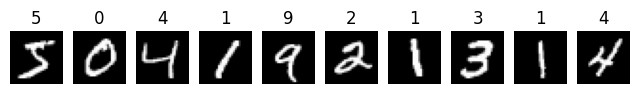

After preprocessing:
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.datasets import mnist

# Load MNIST (digits 0-9))
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Raw train shape:", x_train.shape, "labels:", y_train.shape)
print("Raw test  shape:", x_test.shape, "labels:", y_test.shape)

# Visualise a few training images
plt.figure(figsize=(8, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    plt.title(str(y_train[i]))
plt.show()

# Normalise to [0, 1]
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

# Add channel dimension: (N, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

print("After preprocessing:")
print("Train:", x_train.shape)
print("Test :", x_test.shape)

class_names = [str(i) for i in range(10)]


## 3) <b>✅ Building a small 2D CNN in Keras</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">🧱</span> Model structure</div>
  <ul>
    <li>
      We build a compact CNN:
      <code>Conv2D → ReLU → MaxPool → Conv2D → ReLU → MaxPool → Flatten → Dense → Softmax</code>.
    </li>
    <li>
      The <b>Conv2D</b> layers learn local features.
      Pooling reduces spatial size and helps the network focus on higher-level patterns.
    </li>
    <li>
      The final <code>Dense(10, softmax)</code> outputs class probabilities for digits 0–9.
    </li>
  </ul>
</div>

<div class="box warn">
  <div class="boxtitle"><span class="badge b-warn">⚠️</span> Practical note</div>
  <ul>
    <li>Keep the network small and train for a modest number of epochs, MNIST converges quickly.</li>
    <li>If you make the model very large, you may see overfitting (training accuracy rises faster than validation accuracy).</li>
  </ul>
</div>


In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=16, kernel_size=(3, 3), activation="relu", padding="valid"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="valid"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.7273 - loss: 0.8594 - val_accuracy: 0.9693 - val_loss: 0.1026
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9553 - loss: 0.1501 - val_accuracy: 0.9797 - val_loss: 0.0707
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9667 - loss: 0.1052 - val_accuracy: 0.9822 - val_loss: 0.0588
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9739 - loss: 0.0858 - val_accuracy: 0.9846 - val_loss: 0.0532
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9778 - loss: 0.0717 - val_accuracy: 0.9861 - val_loss: 0.0471
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9815 - loss: 0.0629 - val_accuracy: 0.9864 - val_loss: 0.0495
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.9831 - loss: 0.0545 - val_accuracy: 0.9878 - val_loss: 0.0405
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9835 - loss: 0.0518 - val_accu

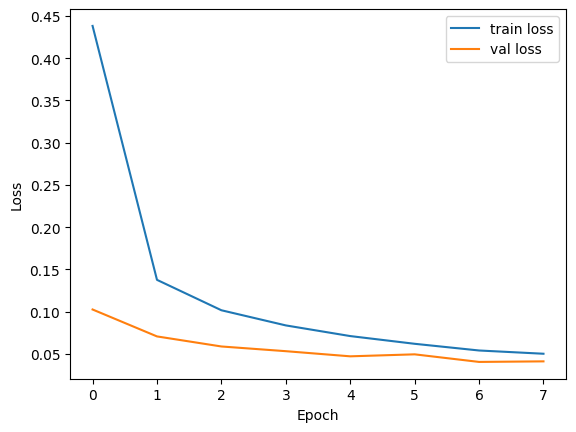

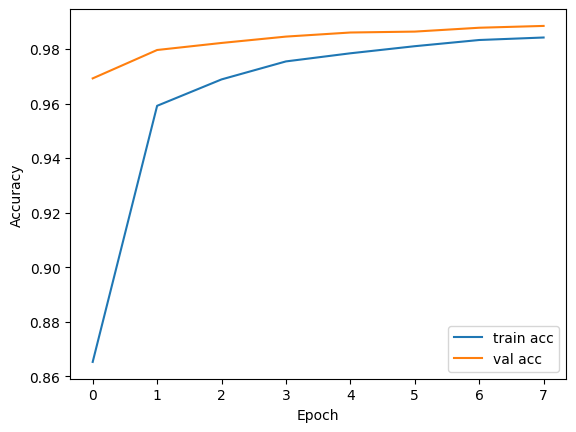

In [ ]:
history = cnn_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    verbose=1
)

# Plot learning curves
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


CNN test accuracy: 0.989

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



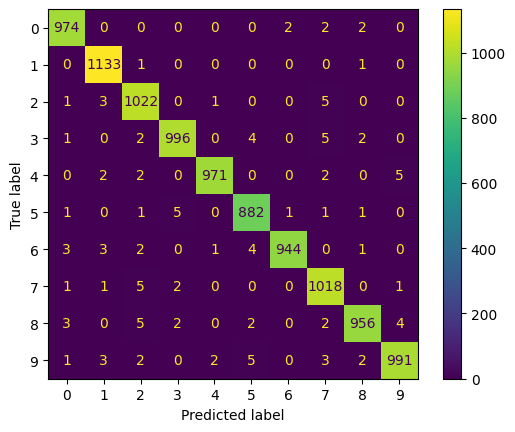

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN test accuracy: {test_acc:.3f}")

y_prob = cnn_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d")
plt.show()


## 4) <b>✅ Baseline comparison, a simple MLP (dense network)</b>

<div class="box">
  <div class="boxtitle"><span class="badge b-info">📌</span> Why compare against an MLP?</div>
  <ul>
    <li>
      A fully connected network (MLP) can also classify images, but it does not exploit spatial structure.
      It treats each pixel as an independent feature after flattening.
    </li>
    <li>
      A CNN usually performs better (and more efficiently) because convolutions reuse weights and learn local patterns.
    </li>
    <li>
      This comparison helps you see <b>why CNNs are the standard choice</b> for image classification.
    </li>
  </ul>
</div>


In [ ]:
mlp_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    verbose=1
)

mlp_loss, mlp_acc = mlp_model.evaluate(x_test, y_test, verbose=0)
print(f"MLP test accuracy: {mlp_acc:.3f}")


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7722 - loss: 0.7782 - val_accuracy: 0.9389 - val_loss: 0.2136
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9291 - loss: 0.2451 - val_accuracy: 0.9553 - val_loss: 0.1559
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9468 - loss: 0.1833 - val_accuracy: 0.9622 - val_loss: 0.1304
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9563 - loss: 0.1517 - val_accuracy: 0.9659 - val_loss: 0.1161
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9599 - loss: 0.1322 - val_accuracy: 0.9688 - val_loss: 0.1069
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9664 - loss: 0.1139 - val_accuracy: 0.9715 - val_loss: 0.0982
Epoch 7/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9681 - loss: 0.1047 - val_accuracy: 0.9726 - val_loss: 0.0929
Epoch 8/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9722 - loss: 0.0920 - val_accuracy: 0.9739 - 

## 5) <b>✅ Exercises</b>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> Exercise 1, Output shapes (must-do)</div>
  <p>
    Suppose the input is <code>28×28×1</code>.
  </p>
  <ol>
    <li>Conv2D with <code>kernel=3</code>, <code>stride=1</code>, <code>padding="valid"</code>, <code>filters=16</code>. What is the output shape?</li>
    <li>MaxPooling2D with <code>pool=2</code>, <code>stride=2</code>. What is the output shape now?</li>
    <li>After a second Conv2D (<code>kernel=3</code>, <code>valid</code>, <code>filters=32</code>) and another pool (2,2), what is the final feature map shape before flattening?</li>
  </ol>
</div>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> Exercise 2, Modify the CNN (overfitting control)</div>
  <ul>
    <li>Increase the model capacity (e.g., more filters, add one more Conv2D block) and re-train.</li>
    <li>Add or adjust <code>Dropout</code>, and compare training vs validation curves.</li>
    <li>Briefly explain what you observe.</li>
  </ul>
</div>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧩</span> Exercise 3, CNN vs MLP (critical thinking)</div>
  <ul>
    <li>Compare CNN vs MLP test accuracy.</li>
    <li>Explain why CNNs typically outperform MLPs on image tasks.</li>
  </ul>
</div>


<details>
  <summary>✅ Answers, Exercise 1 (output shapes)</summary>
  <ul>
    <li><b>1)</b> Conv (3×3, stride 1, valid) from 28×28 gives 26×26. With 16 filters: <code>26×26×16</code>.</li>
    <li><b>2)</b> MaxPool (2×2, stride 2) halves spatial size: <code>13×13×16</code>.</li>
    <li><b>3)</b> Second Conv (3×3, valid) from 13×13 gives 11×11, with 32 filters: <code>11×11×32</code>. After another 2×2 pool: <code>5×5×32</code>.</li>
  </ul>
</details>


<b>✅ Week 9 Tutorial Complete</b>

<p>
  This concludes <b>Week 9, Convolutional Neural Networks (CNNs)</b>.
  You should now be able to explain why CNNs are well-suited to image data (local connectivity and weight sharing), prepare an image dataset (MNIST) by normalising pixel values and adding a channel dimension, and build a basic CNN using <code>Conv2D</code>, <code>ReLU</code>, <code>MaxPooling2D</code>, <code>Flatten</code>, and <code>Dense</code> layers.
  You should also be able to train and evaluate a CNN using a validation split and test set performance, interpret a confusion matrix for multi-class classification, and compare a CNN against a simple MLP baseline.
  Finally, you should be able to inspect learned representations by extracting and visualising activations from early convolutional layers.
</p>

